# Exploratory Data Analysis on E-Commerce Sales Dataset

This project performs Exploratory Data Analysis (EDA) on an E-Commerce sales dataset to identify patterns, trends, customer behavior, and sales insights using Python.

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Connect Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Data Set/Dataset 2.xlsx')

In [ ]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


# Dataset Understanding

In [ ]:
df.shape

(1200, 14)

In [ ]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [ ]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


# Data Cleaning

Check Missing Values

In [ ]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


Fill the missing values

In [ ]:
df['CouponCode'] = df['CouponCode'].fillna('Not use the Coupon')

Check again

In [ ]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


Check Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(0)

# Analysis Process

**Descriptive Statistics**

In [ ]:
df[['Quantity','UnitPrice','TotalPrice']].describe()

,Quantity,UnitPrice,TotalPrice
count,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,1053.968300
std,1.407557,197.177146,819.856558
min,1.000000,11.390000,11.390000
25%,2.000000,186.062500,410.520000
50%,3.000000,364.210000,823.615000
75%,4.000000,521.570000,1578.475000
max,5.000000,699.930000,3456.400000


**Product Analysis**

This section analyzes the most sold products in the dataset to understand customer purchasing behavior.

In [ ]:
df['Product'].value_counts()

,count
Product,
Printer,181
Tablet,179
Chair,178
Laptop,173
Desk,170
Monitor,163
Phone,156


Visualization

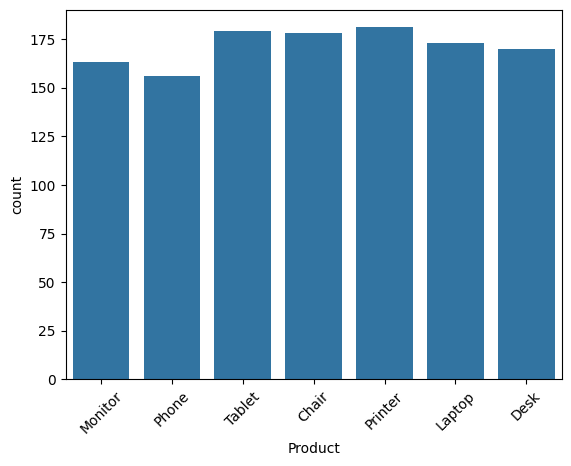

In [ ]:
sns.countplot(x='Product', data=df)
plt.xticks(rotation=45)
plt.show()

**Payment Method Analysis**

In [ ]:
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Online,258
Cash,246
Credit Card,234
Debit Card,232
Gift Card,230


Visualization

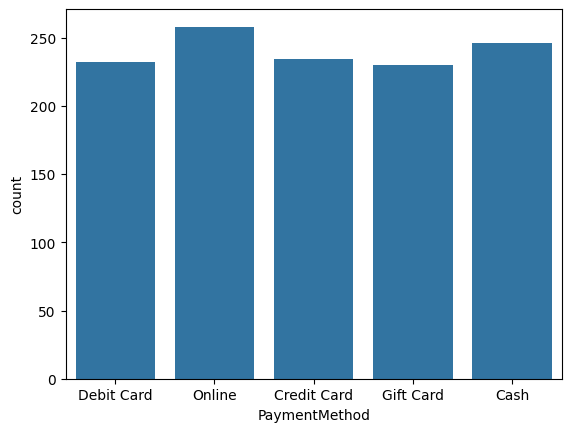

In [ ]:
sns.countplot(x='PaymentMethod', data=df)
plt.show()

**Order Status Analysis**

In [ ]:
df['OrderStatus'].value_counts()

,count
OrderStatus,
Cancelled,250
Returned,247
Pending,237
Shipped,235
Delivered,231


Visualization

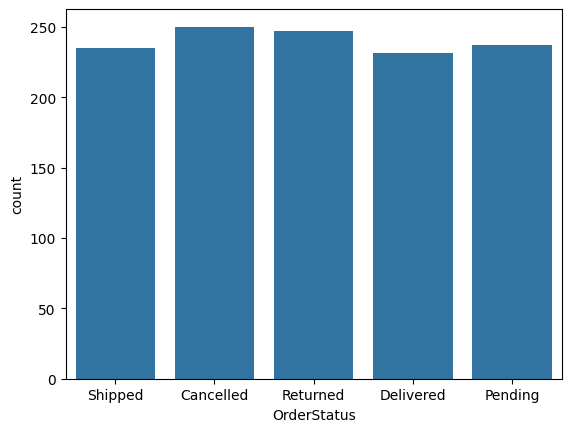

In [ ]:
sns.countplot(x='OrderStatus', data=df)
plt.show()

**Sales Trend Analysis**

Conver Date

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

Monthly sales

In [ ]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()
monthly_sales

,TotalPrice
Month,
1,124313.23
2,112344.78
3,123840.93
4,109186.05
5,135142.59
6,170616.13
7,85784.64
8,86343.21
9,69321.65


Visualization

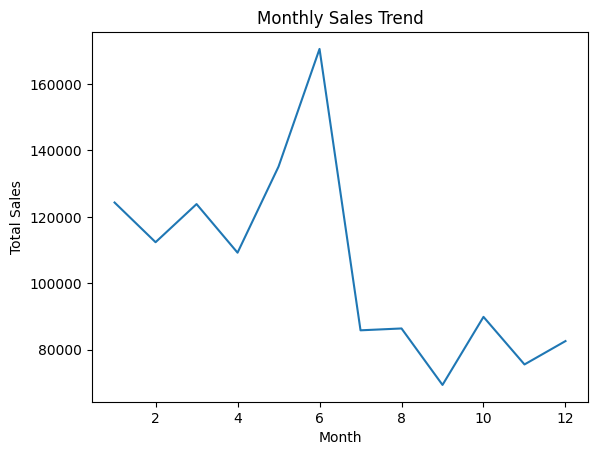

In [ ]:
monthly_sales.plot(kind='line')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')
plt.show()

**Correlation Analysis**

Correlation analysis helps identify relationships between numerical variables in the dataset.

Relationship Between Numerical Variables

In [ ]:
correlation = df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].corr()

Visualization

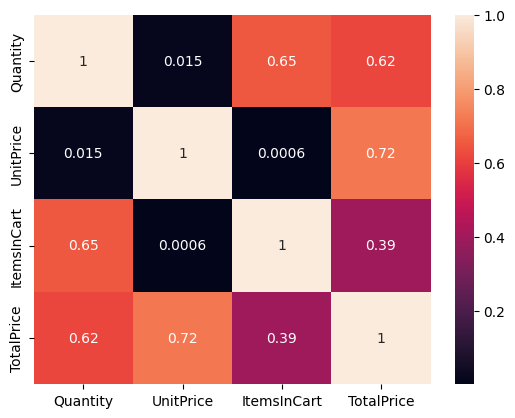

In [ ]:
sns.heatmap(correlation, annot=True)
plt.show()

**Outlier Detection**

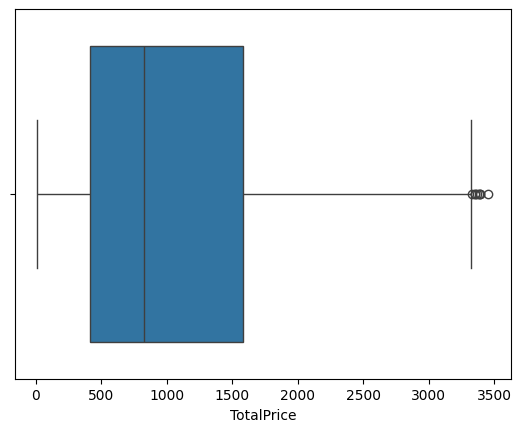

In [ ]:
sns.boxplot(x=df['TotalPrice'])
plt.show()

**Referral Source Analysis**

In [ ]:
df['ReferralSource'].value_counts()

,count
ReferralSource,
Instagram,259
Email,250
Google,241
Facebook,228
Referral,222


Visualization

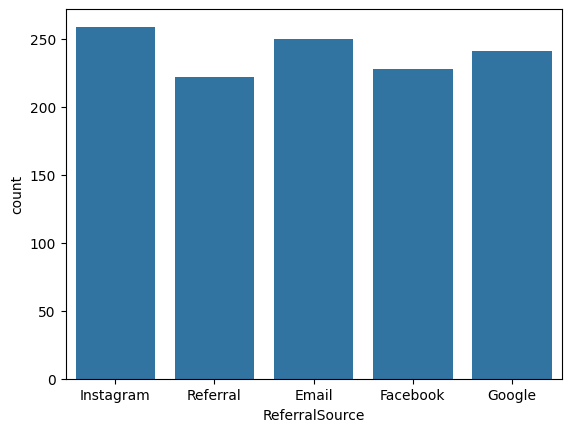

In [ ]:
sns.countplot(x='ReferralSource', data=df)
plt.show()

# Outcomes

*   Monitor and Phone products have high sales.
* Debit Card is the most used payment method.
* Some high-value outliers exist in TotalPrice.
* Sales increase during certain months.
* Social media platforms drive customer traffic.



# Conclusion

This project successfully analyzed an E-Commerce dataset using Exploratory Data Analysis techniques. Statistical analysis and visualizations helped identify trends, customer behavior, sales performance, and outliers within the dataset.